In [ ]:
from pyspark.sql import SparkSession
from pyspark import SparkContext
from pyspark.sql.functions import hour, to_date, year, month, to_timestamp

if __name__ == '__main__':
    spark = SparkSession \
        .builder \
        .appName('My Application') \
        .getOrCreate()
    sc = spark.sparkContext
    # ...
    # Application specific code
    # ..
    spark.stop()

In [ ]:
from pyspark.sql.functions import hour, to_date, year, month, to_timestamp, dayofmonth, when
from datetime import datetime

from pyspark.sql.functions import col, to_date, hour, dayofmonth, month, max, min, avg, count
from datetime import datetime
import logging


In [ ]:
import logging

# Configurar logging (puedes ajustar el formato y el nivel según necesites)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def print_and_log(message):
    print(message)
    logging.info(message)


In [ ]:
# Reinitialize SparkSession and SparkContext
spark = SparkSession \
    .builder \
    .appName('My Application') \
    .getOrCreate()
sc = spark.sparkContext

# 2. Carga os datos nun RDD
# Ruta ao arquivo en HDFS
hdfs_path = 'hdfs:///user/xuedua088/yellow_tripdata_2018-12.csv'

# Cargar os datos no RDD
rdd = sc.textFile(hdfs_path)

# Visualizar as primeiras liñas
rdd.take(5)

In [ ]:
cleaned_rdd = rdd.filter(lambda line: len(line.split(',')) == 19)  # Asumiuse que cada liña ten 19 columnas

In [ ]:
# Define taxi_df from the CSV file
taxi_df = spark.read.csv(hdfs_path, header=True, inferSchema=True)

# Print the schema of the DataFrame
taxi_df.printSchema()

NameError: name 'spark' is not defined

In [ ]:
taxi_df.head(5)

In [ ]:
# Definir ruta de archivo HDFS (ajusta esta variable a tu ruta real)
hdfs_path = 'hdfs:///user/xuedua088/yellow_tripdata_2018-12.csv'

# Leer el archivo CSV desde HDFS
rdd = sc.textFile(hdfs_path)

# Guardar la primera línea como cabecera
header = rdd.first()

# Filtrar la cabecera y líneas vacías
rdd_no_header = rdd.filter(lambda x: x != header)
rdd_cleaned = rdd_no_header.filter(lambda x: x.strip() != '')

# Función para extraer fecha y hora del campo tpep_pickup_datetime (segundo campo)
def extract_hour_and_date(line):
    fields = line.split(',')
    if len(fields) < 2 or not fields[1]:
        return None
    timestamp = fields[1]
    date = timestamp.split(' ')[0]
    hour = int(timestamp.split(' ')[1].split(':')[0])
    return (date, hour)

# Aplicar extracción y filtrar solo las filas con hora == 0
rdd_filtered = rdd_cleaned.map(extract_hour_and_date).filter(lambda x: x is not None and x[1] == 0)

# Contar el número de viajes por día (fecha)
result_rdd = rdd_filtered.map(lambda x: (x[0], 1)).reduceByKey(lambda a, b: a + b)

# Recoger y mostrar resultados
print(result_rdd.collect())


NameError: name 'cleaned_rdd' is not defined

In [ ]:
# Función para extraer mes desde la tupla (date, hour) del RDD
def extract_month(line):
    date = line[0]  # line es (date, hour)
    month = date.split('-')[1]  # Extraemos el mes del formato YYYY-MM-DD
    return (month, 1)

# Aplicar la función sobre rdd_filtered que ya contiene (date, hour)
rdd_filtered_month = rdd_filtered.map(extract_month)

# Reducir para contar por mes
result_month_rdd = rdd_filtered_month.reduceByKey(lambda a, b: a + b)

# Mostrar resultado RDD
print(result_month_rdd.collect())

# --- PARTE DATAFRAME ---

from pyspark.sql import functions as F

# Extraer mes desde la columna correcta 'tpep_pickup_datetime'
df = df.withColumn('month', F.month(F.col('tpep_pickup_datetime')))

# Agrupar por mes y contar
result_month_df = df.groupBy('month').count()

# Mostrar resultado DataFrame
result_month_df.show()


In [ ]:
def extract_vendor_and_month(line):
    fields = line.split(',')
    vendor_id = fields[2]  # VendorID
    timestamp = fields[1]
    month = timestamp.split('-')[1]  # Mes extraído
    return (vendor_id, month)

rdd_vendor_month = cleaned_rdd.map(extract_vendor_and_month)
result_vendor_month_rdd = rdd_vendor_month.map(lambda x: ((x[0], x[1]), 1)).reduceByKey(lambda a, b: a + b)
result_vendor_month_rdd.collect()

df = df.withColumn('vendor_id', df['VendorID'])

# Calcular media de viaxes por conductor ao mes
result_vendor_month_df = df.groupBy('vendor_id', 'month').count()
result_vendor_month_df.show()

In [ ]:
def extract_vendor_and_day_rdd(line):
    fields = line.split(',')
    vendor_id = fields[2]  # VendorID
    timestamp = fields[1]  # tpep_pickup_datetime
    day = timestamp.split(' ')[0]  # Extraemos el día (YYYY-MM-DD)
    return (vendor_id, day)

# Mapeamos para obtener VendorID y día
rdd_vendor_day = cleaned_rdd.map(extract_vendor_and_day_rdd)

# Contamos viajes por VendorID y día
vendor_day_counts = rdd_vendor_day.map(lambda x: ((x[0], x[1]), 1)).reduceByKey(lambda a, b: a + b)

print(vendor_day_counts.collect())

# En el DataFrame, creamos columna 'day' a partir de tpep_pickup_datetime
df = df.withColumn('day', F.to_date(F.col('tpep_pickup_datetime')))

# Contamos viajes por VendorID y día
vendor_day_df = df.groupBy('VendorID', 'day').count()

# Calculamos media de viajes por día y VendorID
vendor_day_avg_df = vendor_day_df.groupBy('VendorID').agg(F.avg('count').alias('avg_trips_per_day'))

vendor_day_avg_df.show()


In [ ]:
def extract_passenger_and_date_rdd(line):
    fields = line.split(',')
    passengers = int(fields[9])  # Número de pasajeros en columna 9
    timestamp = fields[1]        # tpep_pickup_datetime
    date = timestamp.split(' ')[0]
    return (date, passengers)

# Filtrar viajes en la primera semana del mes
rdd_filtered_week = cleaned_rdd.map(extract_passenger_and_date_rdd)
rdd_filtered_week = rdd_filtered_week.filter(lambda x: int(x[0].split('-')[2]) <= 7)

# Número máximo de pasajeros en la primera semana
max_passengers_first_week = rdd_filtered_week.map(lambda x: x[1]).max()
print(max_passengers_first_week)


from pyspark.sql import functions as F

# Añadir columna 'day' con el día del mes a partir de tpep_pickup_datetime
df = df.withColumn('day', F.dayofmonth(F.col('tpep_pickup_datetime')))

# Filtrar viajes de la primera semana
df_first_week = df.filter(df['day'] <= 7)

# Obtener máximo número de pasajeros en esa semana
max_passengers_first_week_df = df_first_week.agg(F.max('passenger_count').alias('max_passengers'))
max_passengers_first_week_df.show()


In [ ]:
def extract_passenger_and_month_rdd(line):
    fields = line.split(',')
    passengers = int(fields[9])
    timestamp = fields[1]
    month = timestamp.split('-')[1]  # Extraemos el mes
    return (month, passengers)

# Mapeamos para obtener mes y pasajeros
rdd_filtered_month = cleaned_rdd.map(extract_passenger_and_month_rdd)

# Máximo de pasajeros en todo el mes (en RDD)
max_passengers_all_month = rdd_filtered_month.map(lambda x: x[1]).max()
print(max_passengers_all_month)


from pyspark.sql import functions as F

# Añadimos columna 'month' en DataFrame
df = df.withColumn('month', F.month(F.col('tpep_pickup_datetime')))

# Obtenemos el máximo número de pasajeros
max_passengers_all_month_df = df.agg(F.max('passenger_count').alias('max_passengers'))
max_passengers_all_month_df.show()


In [ ]:
def extract_cost_rdd(line):
    fields = line.split(',')
    cost = float(fields[16])  # Suponemos que el costo está en la columna 16
    return cost

# Extraemos los costos de las carreras
rdd_costs = cleaned_rdd.map(extract_cost_rdd)

# Obtenemos el costo máximo
max_cost = rdd_costs.max()
print(max_cost)

df = df.withColumn('cost', df['total_amount'])  # Suponemos que el costo está en 'total_amount'

# Obtenemos el costo máximo
max_cost_df = df.agg(F.max('cost').alias('max_cost'))
max_cost_df.show()

In [ ]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StructType, StructField, DoubleType, StringType

# -------------------------
# Crear SparkSession si no existe
# -------------------------
spark = SparkSession.builder.getOrCreate()

# -------------------------
# Cargar y limpiar RDD
# -------------------------
rdd = sc.textFile("hdfs:///user/xuedua088/yellow_tripdata_2018-12.csv")
header = rdd.first()
cleaned_rdd = rdd.filter(lambda line: line != header)

# -------------------------
# RDD: Extracción y mínimo
# -------------------------
def extract_cost_rdd(line):
    fields = line.split(',')
    if len(fields) > 16:
        try:
            cost = float(fields[16])
            return cost
        except ValueError:
            return None
    else:
        return None

rdd_costs = cleaned_rdd.map(extract_cost_rdd).filter(lambda cost: cost is not None and cost >= 0)
min_cost_rdd = rdd_costs.min()
print("Costo mínimo (RDD):", min_cost_rdd)

# -------------------------
# DataFrame: creación, filtrado y mínimo
# -------------------------
# Creamos el schema simplificado para solo la columna 'cost'
schema = StructType([
    StructField("dummy1", StringType(), True),
    StructField("dummy2", StringType(), True),
    StructField("dummy3", StringType(), True),
    StructField("dummy4", StringType(), True),
    StructField("dummy5", StringType(), True),
    StructField("dummy6", StringType(), True),
    StructField("dummy7", StringType(), True),
    StructField("dummy8", StringType(), True),
    StructField("dummy9", StringType(), True),
    StructField("dummy10", StringType(), True),
    StructField("dummy11", StringType(), True),
    StructField("dummy12", StringType(), True),
    StructField("dummy13", StringType(), True),
    StructField("dummy14", StringType(), True),
    StructField("dummy15", StringType(), True),
    StructField("dummy16", StringType(), True),
    StructField("cost", DoubleType(), True)  
])

df = spark.read.csv("hdfs:///user/xuedua088/yellow_tripdata_2018-12.csv", header=True, schema=schema)
df = df.filter(F.col("cost").isNotNull())

min_cost_df = df.filter(F.col("cost") >= 0).agg(F.min("cost").alias("min_cost"))
min_cost_df.show()


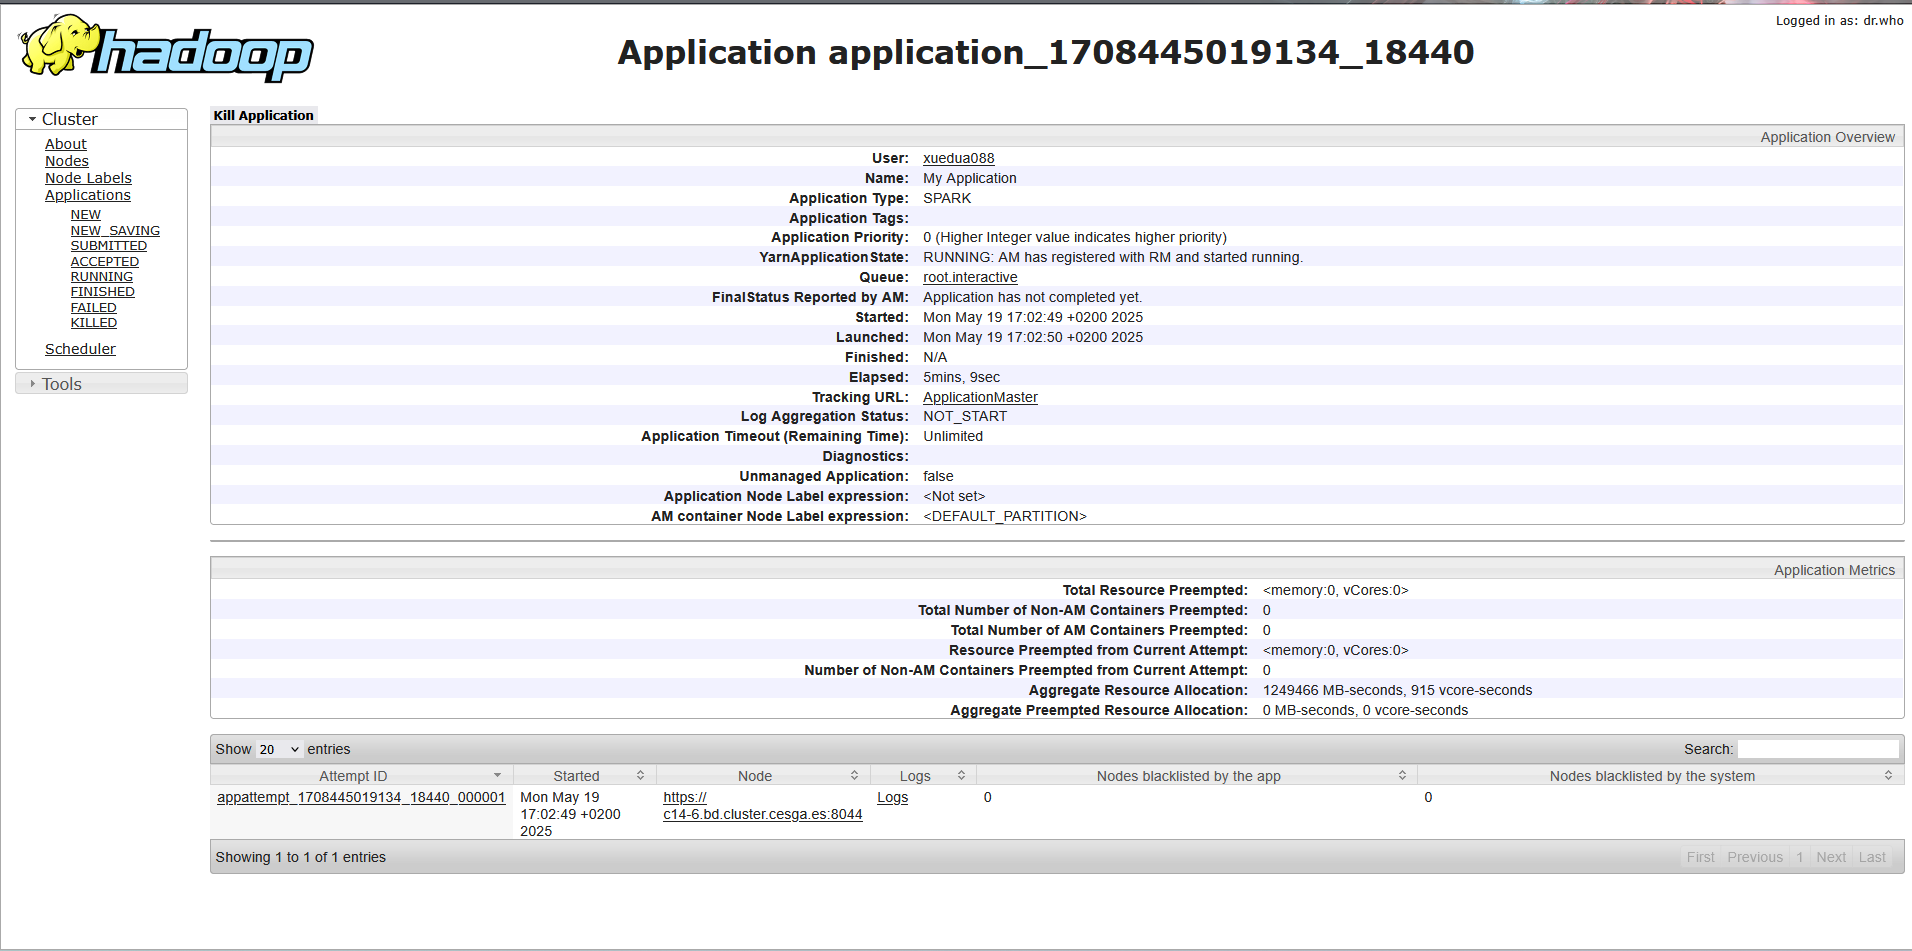

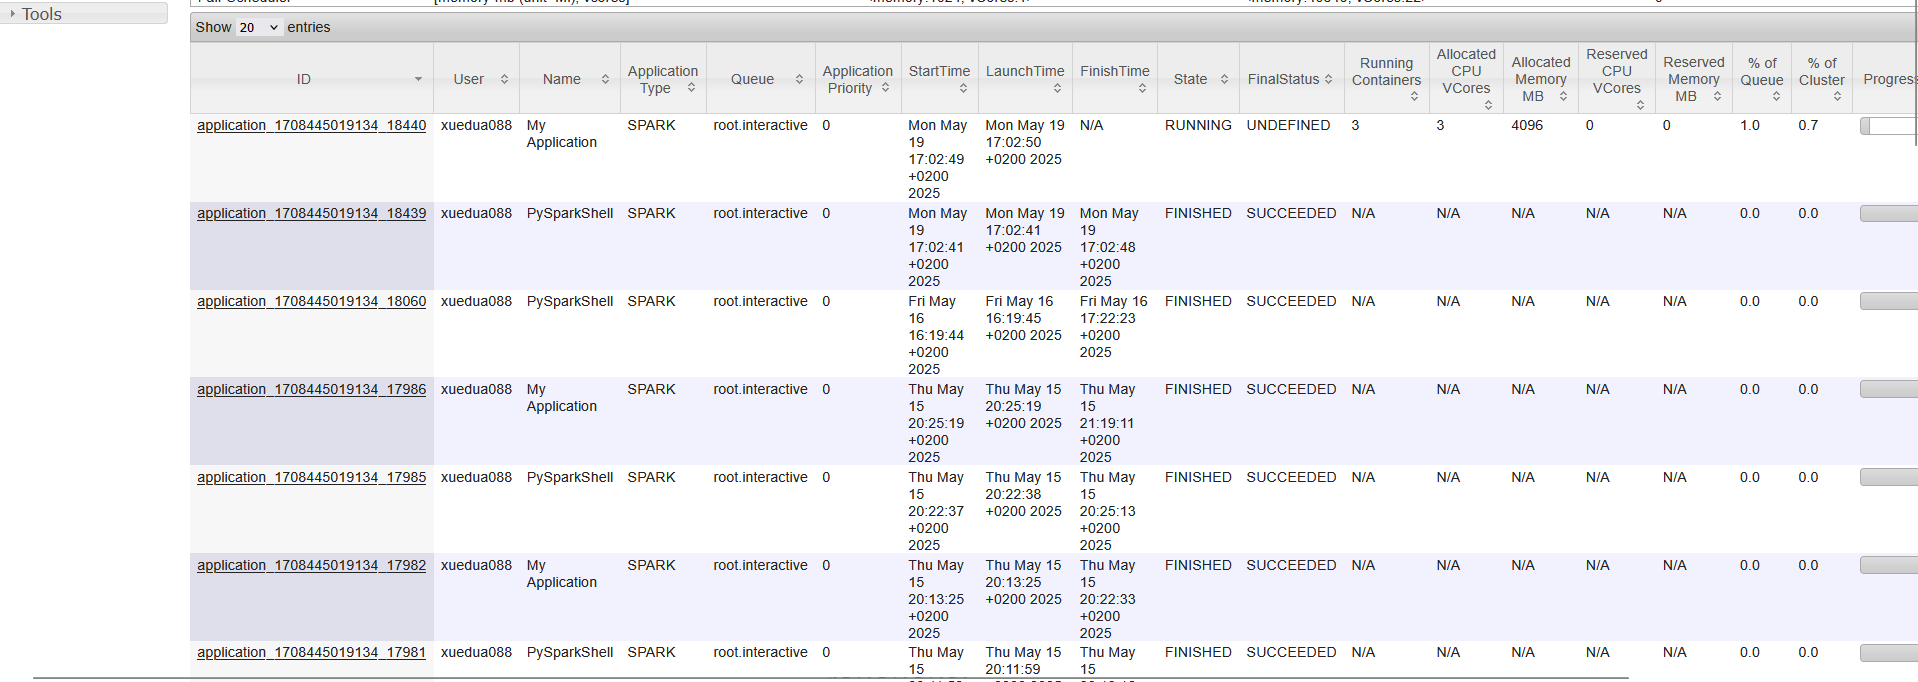